In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Loss

   step      loss
0     1  8.149048
1     2  8.364526
2     3  9.082062
3     4  7.887124
4     5  7.850564
   step      loss
0   200  4.949389
1   400  4.516305
2   600  4.284067
3   800  4.145406
4  1000  4.058169


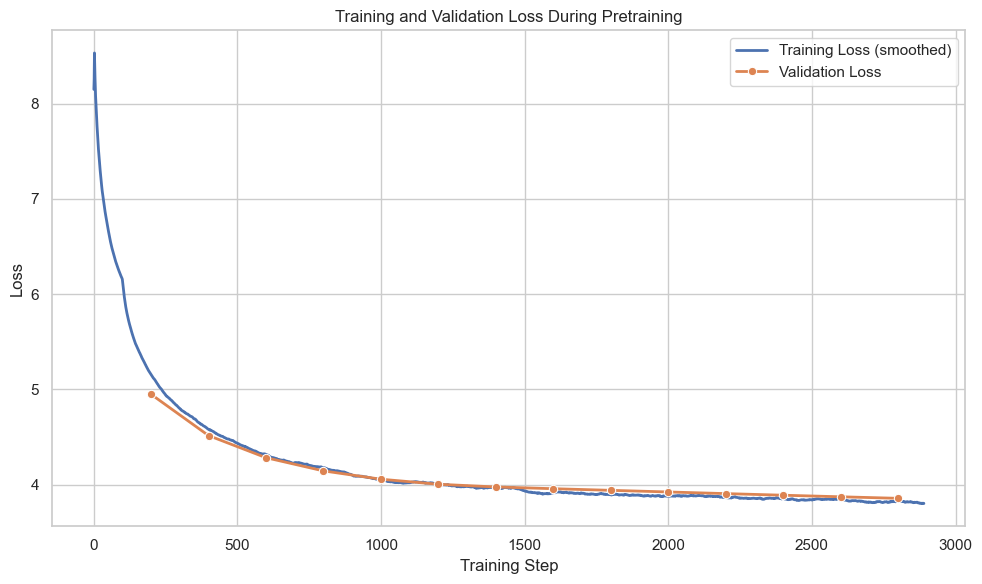

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_loss_path = "losses/openhermes/openhermes_train_losses.txt"
val_loss_path = "losses/openhermes/openhermes_val_losses.txt"

train_df = pd.read_csv(train_loss_path)
val_df = pd.read_csv(val_loss_path)

# Eğer kolon isimleri farklıysa burayı kontrol et
print(train_df.head())
print(val_df.head())

# Smooth training loss
train_df["smoothed_loss"] = train_df["loss"].rolling(window=100, min_periods=1).mean()

# İlk validation loss çok büyükse grafiği bozuyor, onu ayrı tutuyoruz
val_df_plot = val_df[val_df["step"] > 0]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=train_df,
    x="step",
    y="smoothed_loss",
    label="Training Loss (smoothed)",
    linewidth=2
)

sns.lineplot(
    data=val_df_plot,
    x="step",
    y="loss",
    label="Validation Loss",
    marker="o",
    linewidth=2
)

plt.title("Training and Validation Loss During Pretraining")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Vectorel Analysis

In [13]:
import torch
from model import Config, DecoderModel
device = "mps" if torch.backends.mps.is_available() else "cpu"

it_ckpt_path = "../checkpoints/openhermes_instruction_tuned_decoder.pt"
pretrained_ckpt_path = "../checkpoints/pretrained_decoder.pt"
random_ckpt_path = "../checkpoints/random_decoder.pt"


In [14]:
random_checkpoint = torch.load(random_ckpt_path, map_location=device, weights_only=False)

random_config = random_checkpoint["config"]
print(random_config)

random_config = {
    "vocab_size": 50257,
    "d_model": 256,
    "n_head": 4,
    "n_layers": 4,
    "block_size": 128,
    "intermediate_size": 1024
}

if isinstance(random_config, dict):
    random_config = Config(**random_config)

random_model = DecoderModel(random_config, device=device)
random_model.load_state_dict(random_checkpoint["model_state_dict"])
random_model.eval()

Config(vocab_size=50257, d_model=256, n_head=4, n_layers=4, block_size=128, intermediate_size=1024, head_dim=64)


DecoderModel(
  (embedding): Embedding(50257, 256)
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attention): Attention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (wo): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (up_proj): Linear(in_features=256, out_features=1024, bias=True)
        (down_proj): Linear(in_features=1024, out_features=256, bias=True)
        (act_fn): SiLU()
      )
      (norm_1): RMSNorm((256,), eps=None, elementwise_affine=True)
      (norm_2): RMSNorm((256,), eps=None, elementwise_affine=True)
    )
  )
  (norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=50257, bias=True)
)

In [15]:
pretrained_checkpoint = torch.load(pretrained_ckpt_path, map_location=device, weights_only=False)

pretrained_config = pretrained_checkpoint["config"]
print(pretrained_config)

pretrained_config = {
    "vocab_size": 50257,
    "d_model": 256,
    "n_head": 4,
    "n_layers": 4,
    "block_size": 128,
    "intermediate_size": 1024
}

if isinstance(pretrained_config, dict):
    pretrained_config = Config(**pretrained_config)

pretrained_model = DecoderModel(pretrained_config, device=device)
pretrained_model.load_state_dict(pretrained_checkpoint["model_state_dict"])
pretrained_model.eval()

Config(vocab_size=50257, d_model=256, n_head=4, n_layers=4, block_size=128, intermediate_size=1024, head_dim=64)


DecoderModel(
  (embedding): Embedding(50257, 256)
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attention): Attention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (wo): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (up_proj): Linear(in_features=256, out_features=1024, bias=True)
        (down_proj): Linear(in_features=1024, out_features=256, bias=True)
        (act_fn): SiLU()
      )
      (norm_1): RMSNorm((256,), eps=None, elementwise_affine=True)
      (norm_2): RMSNorm((256,), eps=None, elementwise_affine=True)
    )
  )
  (norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=50257, bias=True)
)

In [16]:
finetuned_checkpoint = torch.load(it_ckpt_path, map_location=device, weights_only=False)
finetuned_config = finetuned_checkpoint["config"]
print(finetuned_config)
finetuned_config = {'vocab_size': 50257, 'd_model': 256, 'n_head': 4, 'n_layers': 4, 'block_size': 128, 'intermediate_size': 1024}
if isinstance(finetuned_config, dict):
    finetuned_config = Config(**finetuned_config)
finetuned_model = DecoderModel(finetuned_config, device=device)
finetuned_model.load_state_dict(finetuned_checkpoint["model_state_dict"])
finetuned_model.eval()

{'vocab_size': 50257, 'd_model': 256, 'n_head': 4, 'n_layers': 4, 'block_size': 128, 'intermediate_size': 1024, 'head_dim': 64}


DecoderModel(
  (embedding): Embedding(50257, 256)
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attention): Attention(
        (Wq): Linear(in_features=256, out_features=256, bias=True)
        (Wk): Linear(in_features=256, out_features=256, bias=True)
        (Wv): Linear(in_features=256, out_features=256, bias=True)
        (wo): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (up_proj): Linear(in_features=256, out_features=1024, bias=True)
        (down_proj): Linear(in_features=1024, out_features=256, bias=True)
        (act_fn): SiLU()
      )
      (norm_1): RMSNorm((256,), eps=None, elementwise_affine=True)
      (norm_2): RMSNorm((256,), eps=None, elementwise_affine=True)
    )
  )
  (norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=50257, bias=True)
)

In [17]:
print(finetuned_config)
x = torch.randint(
    low=0,
    high=finetuned_config.vocab_size,
    size=(1, finetuned_config.block_size),
    dtype=torch.long
).to(device)

with torch.no_grad():
    logits = finetuned_model(x)

print(logits.shape)

Config(vocab_size=50257, d_model=256, n_head=4, n_layers=4, block_size=128, intermediate_size=1024, head_dim=64)
torch.Size([1, 128, 50257])


# Get Answer From Model

In [18]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
print("OK")

OK


In [19]:
import json
import torch


def build_finetuned_prompt(query):
    prompt = (
        "System:\n"
        "You are a helpful assistant.\n\n"
        "User:\n"
        f"{query.strip()}\n\n"
        "Assistant:\n"
    )
    return prompt


def generate_text(
    model,
    text,
    tokenizer,
    device,
    max_new_tokens=64,
    use_chat_prompt=False,
    eos_token_id=None
):
    model.eval()

    if use_chat_prompt:
        input_text = build_finetuned_prompt(text)
    else:
        input_text = text

    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            output = model(input_ids)

            # output shape: [B, T, vocab_size]
            logits = output[:, -1, :]  # [B, vocab_size]

            next_token = torch.argmax(
                logits,
                dim=-1,
                keepdim=True
            )  # [B, 1]

            input_ids = torch.cat(
                [input_ids, next_token],
                dim=1
            )  # [B, T + 1]

            if eos_token_id is not None and next_token.item() == eos_token_id:
                break

    decoded_text = tokenizer.decode(
        input_ids[0],
        skip_special_tokens=True
    )

    return decoded_text


def compare_models_on_messages(
    messages,
    pretrained_model,
    finetuned_model,
    tokenizer,
    device,
    output_json_path="model_outputs.json",
    max_new_tokens=64
):
    results = []

    eos_token_id = tokenizer.eos_token_id

    for idx, message in enumerate(messages):
        pretrained_output = generate_text(
            model=pretrained_model,
            text=message,
            tokenizer=tokenizer,
            device=device,
            max_new_tokens=max_new_tokens,
            use_chat_prompt=False,
            eos_token_id=eos_token_id
        )

        finetuned_output = generate_text(
            model=finetuned_model,
            text=message,
            tokenizer=tokenizer,
            device=device,
            max_new_tokens=max_new_tokens,
            use_chat_prompt=True,
            eos_token_id=eos_token_id
        )

        result = {
            "id": idx,
            "input_message": message,
            "pretrained": {
                "input_format": "raw_message",
                "output": pretrained_output
            },
            "finetuned": {
                "input_format": "instruction_prompt",
                "prompt": build_finetuned_prompt(message),
                "output": finetuned_output
            }
        }

        results.append(result)

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=4)

    return results

In [ ]:
messages = [
    "Who are you?",
    "What can you do?",
    "Explain what artificial intelligence is.",
    "Write a short story about a robot.",
    "How can I learn deep learning?"
]

results = compare_models_on_messages(
    messages=messages,
    pretrained_model=pretrained_model,
    finetuned_model=finetuned_model,
    tokenizer=tokenizer,
    device=device,
    output_json_path="pretrained_vs_finetuned_outputs.json",
    max_new_tokens=64
)